In [6]:
library(shazam)

db <- read.table(
  "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/data/output/repertorio_A_insilico_400_seqs_db-pass.tsv",
  header = TRUE,
  sep = "\t"
)

dist <- distToNearest(
  db,
  sequenceColumn = "junction",
  vCallColumn = "v_call",
  jCallColumn = "j_call",
  model = "ham",
  normalize = "len"
)$dist_nearest

dist <- dist[!is.na(dist)]

out <- findThreshold(dist, method = "density")

out@threshold

Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"


[1] NA

In [19]:
library(shazam)

# 1. Cargar tu base de datos
db <- read.table(
  "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/data/output/repertorio_B_insilico_102400_seqs_db-pass.tsv",
  header = TRUE,
  sep = "\t"
)

# 2. Calcular distancias (Tu código base)
dist <- distToNearest(
  db,
  sequenceColumn = "junction",
  vCallColumn = "v_call",
  jCallColumn = "j_call",
  model = "ham",
  normalize = "len"
)$dist_nearest

# Limpiar los NA para el análisis
dist <- dist[!is.na(dist)]

# 3. ADAPTACIÓN A GMM: 
# Reemplazamos "density" por "gmm". 
# Usamos el modelo "norm-norm" y el corte "optimal" para hallar el umbral matemático.
out <- findThreshold(
  dist, 
  method = "gmm", 
  model = "norm-norm", 
  cutoff = "optimal"
)

# 4. Extraer el umbral calculado por el modelo de mixtura
threshold_final <- out@threshold

# Mostrar el resultado en la consola
print(paste("El umbral calculado por GMM es:", threshold_final))

Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
n = 101999 >= max_n{n in table} = 72000 -- using that as asymptotic value.



[1] "El umbral calculado por GMM es: 0.148168751170891"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0167  0.0877  0.1296  0.1428  0.1875  0.6061 

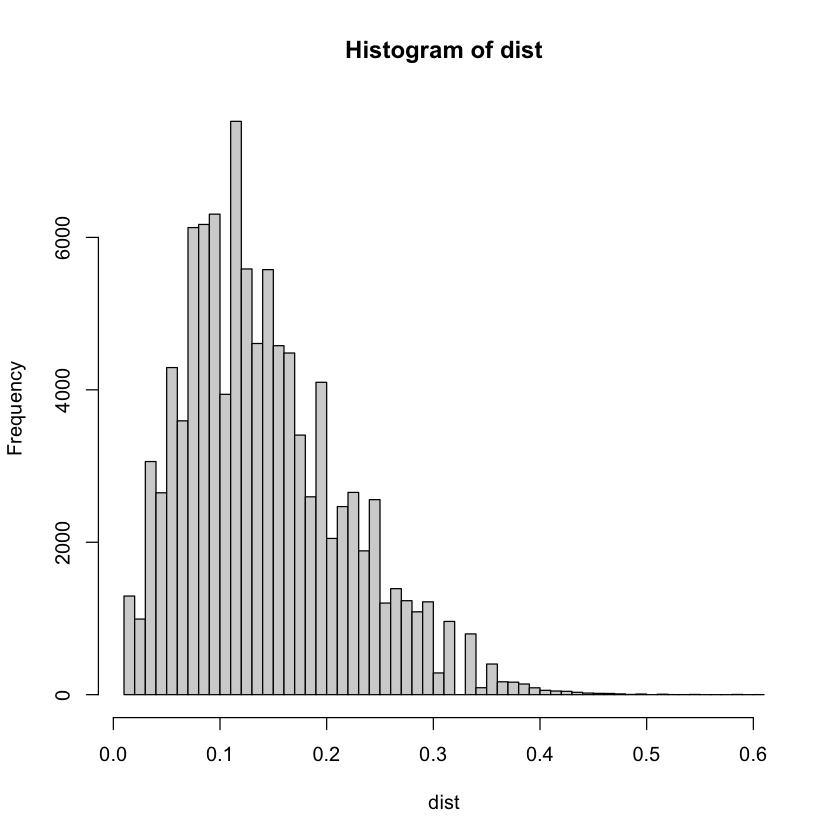

In [20]:
hist(dist, breaks = 50)
summary(dist)

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


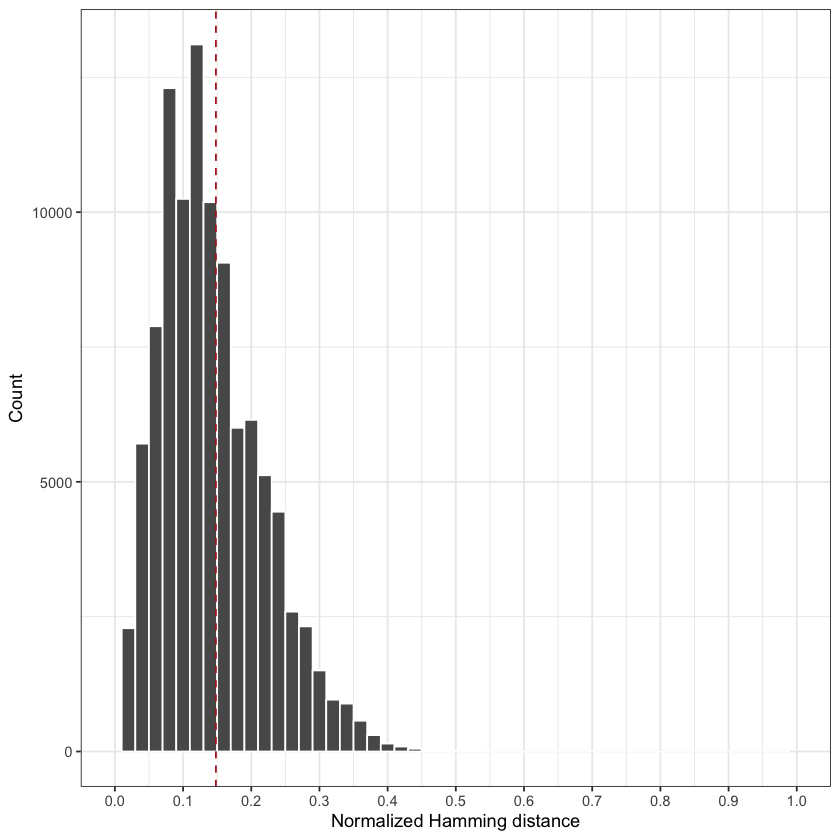

In [22]:
library(ggplot2)

threshold <- out@threshold

p1 <- ggplot(data.frame(dist = dist), aes(x = dist)) +
  geom_histogram(
    color = "white",
    binwidth = 0.02
  ) +
  geom_vline(
    xintercept = threshold,
    color = "firebrick",
    linetype = 2
  ) +
  labs(
    x = "Normalized Hamming distance",
    y = "Count"
  ) +
  scale_x_continuous(
    breaks = seq(0, 1, 0.1),
    limits = c(0, 1)
  ) +
  theme_bw()

p1